In [2]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

n = 50          # number of bees
iters = 80
dim = 2
bounds = np.array([[-5, 5], [-5, 5]])
goal = np.array([2.5, -1.5])

bee = np.random.uniform(bounds[:, 0], bounds[:, 1], size=(n, dim))
trials = np.zeros(n, dtype=int)

traj = np.zeros((iters + 1, n, dim))
traj[0] = bee
best_hist = []

def cost(x):
    d_goal = np.sum((x - goal) ** 2, axis=-1)
    obstacle1 = 12.0 * np.exp(-np.sum((x - np.array([-1.0, 1.0])) ** 2, axis=-1) / 3.0)
    obstacle2 = 8.0 * np.exp(-np.sum((x - np.array([3.0, -2.0])) ** 2, axis=-1) / 4.0)
    return d_goal + obstacle1 + obstacle2

for t in range(iters):
    vals = cost(bee)

    # Employed bees
    for i in range(n):
        k = np.random.randint(n)
        while k == i:
            k = np.random.randint(n)
        phi = np.random.uniform(-1, 1, size=dim)
        cand = bee[i] + phi * (bee[i] - bee[k])
        cand = np.clip(cand, bounds[:, 0], bounds[:, 1])
        if cost(cand) < vals[i]:
            bee[i] = cand
            trials[i] = 0
        else:
            trials[i] += 1

    # Onlooker bees
    vals = cost(bee)
    probs = vals.min() - vals + 1e-9
    probs = probs / probs.sum()

    new_trials = trials.copy()
    for _ in range(n):
        i = np.random.choice(n, p=probs)
        k = np.random.randint(n)
        while k == i:
            k = np.random.randint(n)
        phi = np.random.uniform(-1, 1, size=dim)
        cand = bee[i] + phi * (bee[i] - bee[k])
        cand = np.clip(cand, bounds[:, 0], bounds[:, 1])
        if cost(cand) < cost(bee[i]):
            bee[i] = cand
            new_trials[i] = 0

    # Scout bees
    mask = new_trials > 20
    if np.any(mask):
        bee[mask] = np.random.uniform(bounds[:, 0], bounds[:, 1], size=(np.sum(mask), dim))
        new_trials[mask] = 0
    trials = new_trials

    traj[t + 1] = bee
    best_hist.append(cost(bee).min())

# Plot final positions
plt.figure(figsize=(8, 8), dpi=160)
xx = np.linspace(bounds[0, 0], bounds[0, 1], 300)
yy = np.linspace(bounds[1, 0], bounds[1, 1], 300)
X, Y = np.meshgrid(xx, yy)
Z = (X - goal[0]) ** 2 + (Y - goal[1]) ** 2
Z += 12.0 * np.exp(-((X + 1.0) ** 2 + (Y - 1.0) ** 2) / 3.0)
Z += 8.0 * np.exp(-((X - 3.0) ** 2 + (Y + 2.0) ** 2) / 4.0)

plt.contourf(X, Y, Z, levels=40, cmap="plasma", alpha=0.75)
plt.colorbar(label="Cost")

plt.plot(bee[:, 0], bee[:, 1], "o", color="lightgreen", markersize=6, alpha=0.8, label="Bees (final)")
plt.scatter(bee[:, 0], bee[:, 1], color="darkgreen", s=18, edgecolors="black", linewidth=0.7)

best_idx = np.argmin(cost(bee))
plt.scatter(bee[best_idx, 0], bee[best_idx, 1],
            c="yellow", s=180, marker="*", edgecolors="black", linewidth=1.5, label="Best bee")

plt.scatter(goal[0], goal[1], c="cyan", s=140, marker="*", edgecolors="black", linewidth=1.5, label="Goal")
plt.title("Artificial Bee Colony (50 bees, final positions)")
plt.xlim(bounds[0])
plt.ylim(bounds[1])
plt.legend(loc="upper left", fontsize=8, ncols=2)
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

# Plot convergence
plt.figure(figsize=(8, 3.5), dpi=160)
plt.plot(best_hist, linewidth=2, color="darkgreen")
plt.xlabel("Iteration")
plt.ylabel("Best cost")
plt.title("ABC Convergence")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

ValueError: probabilities are not non-negative

### Bee Colony

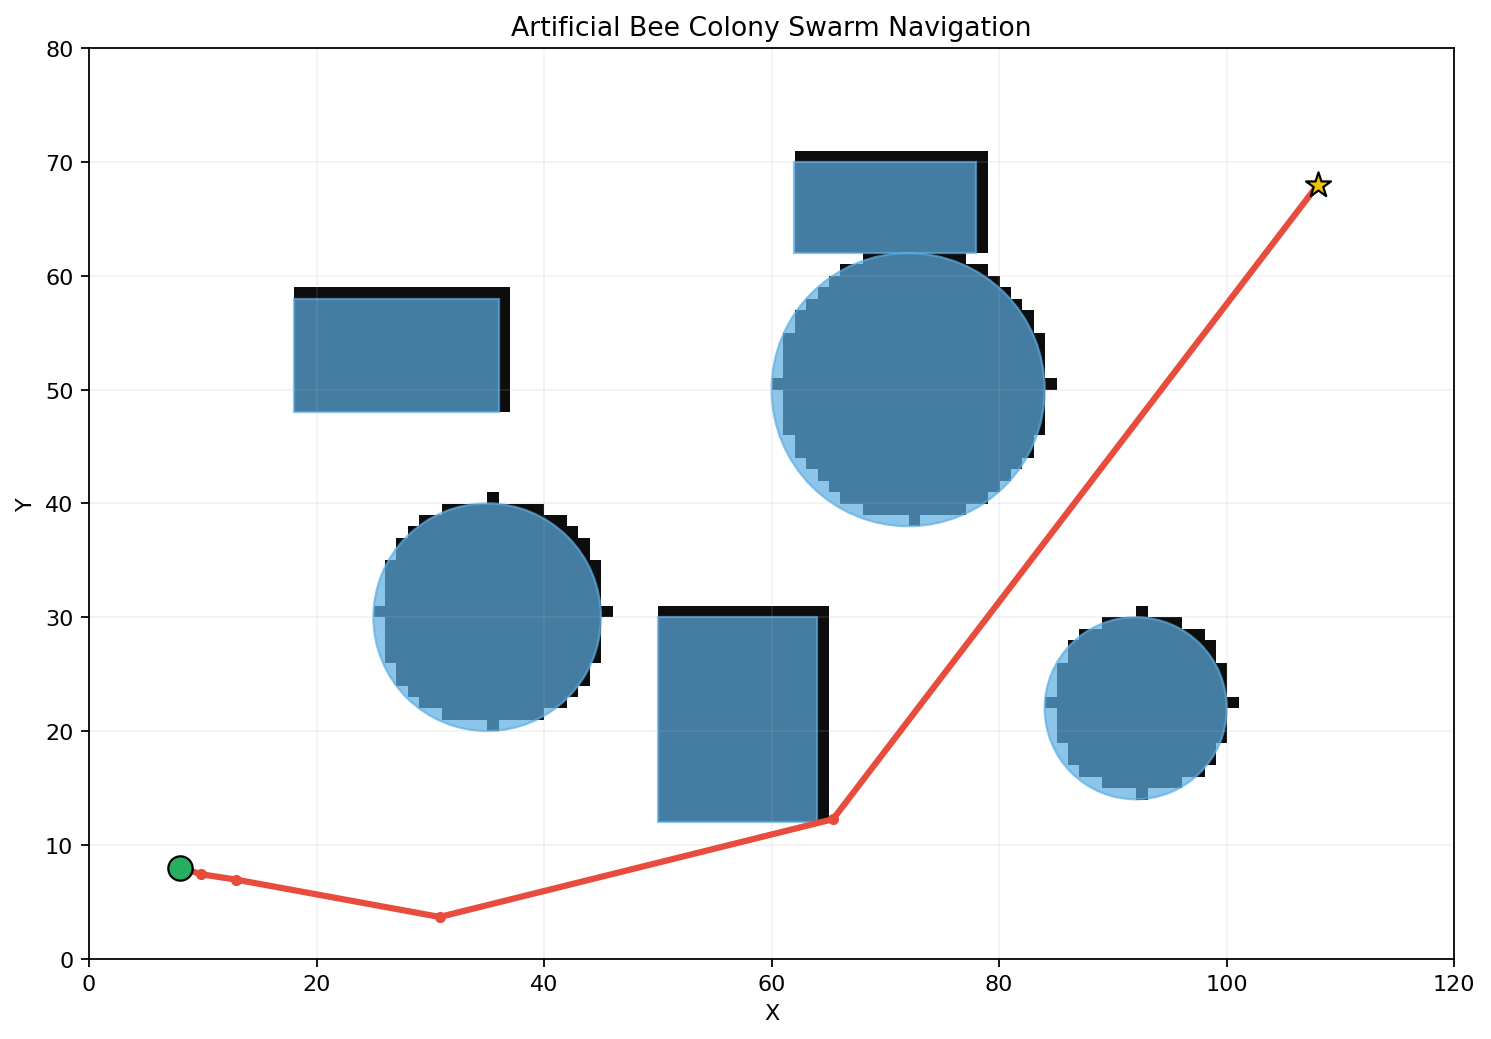

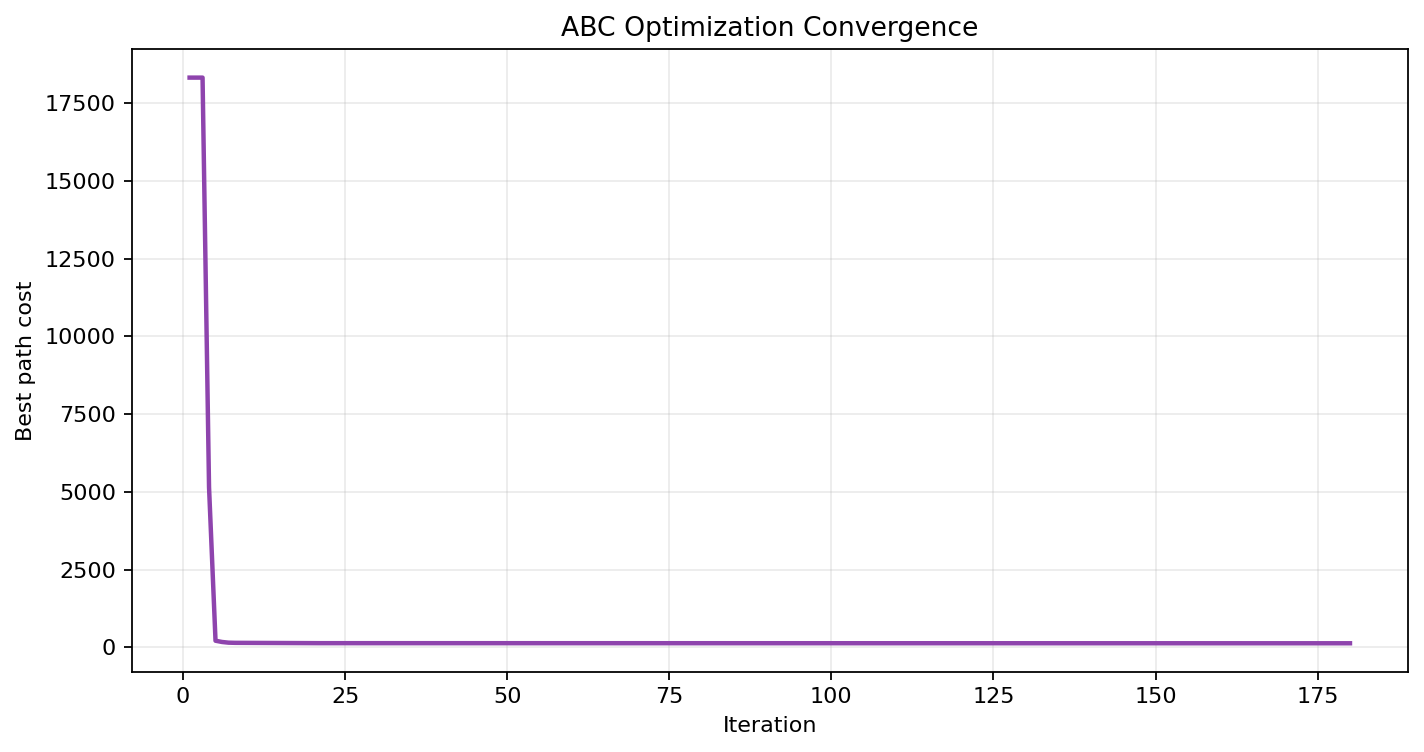

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(7)

# -----------------------------
# Environment
# -----------------------------
W, H = 120, 80
start = np.array([8.0, 8.0])
goal = np.array([108.0, 68.0])

circles = [(35, 30, 10), (72, 50, 12), (92, 22, 8)]
rects = [(18, 48, 18, 10), (50, 12, 14, 18), (62, 62, 16, 8)]

xx, yy = np.meshgrid(np.arange(W), np.arange(H))
occ = np.zeros((H, W), dtype=bool)
for cx, cy, r in circles:
    occ |= (xx - cx) ** 2 + (yy - cy) ** 2 <= r ** 2
for x, y, w, h in rects:
    occ |= (xx >= x) & (xx <= x + w) & (yy >= y) & (yy <= y + h)

# -----------------------------
# ABC parameters
# -----------------------------
n_bees = 35
n_iters = 180
k_waypoints = 4
limit = 20

# -----------------------------
# Helpers
# -----------------------------
def valid_point(p):
    x = int(np.clip(p[0], 0, W - 1))
    y = int(np.clip(p[1], 0, H - 1))
    return not occ[y, x]

def repair_point(p):
    p = np.array(p, dtype=float)
    p[0] = np.clip(p[0], 0, W - 1)
    p[1] = np.clip(p[1], 0, H - 1)
    for _ in range(50):
        if valid_point(p):
            return p
        p += np.random.uniform(-3, 3, size=2)
        p[0] = np.clip(p[0], 0, W - 1)
        p[1] = np.clip(p[1], 0, H - 1)
    return p

def segment_cost(a, b):
    n = max(2, int(np.linalg.norm(b - a) * 1.5))
    pts = np.linspace(a, b, n)
    cost = 0.0
    for i in range(len(pts) - 1):
        p, q = pts[i], pts[i + 1]
        cost += np.linalg.norm(q - p)
        mid = (p + q) / 2
        xm, ym = int(np.clip(mid[0], 0, W - 1)), int(np.clip(mid[1], 0, H - 1))
        if occ[ym, xm]:
            cost += 1000
    return cost

def path_cost(vec):
    pts = [start] + [repair_point(vec[i:i+2]) for i in range(0, len(vec), 2)] + [goal]
    cost = 0.0
    for a, b in zip(pts[:-1], pts[1:]):
        cost += segment_cost(a, b)
    for i in range(1, len(pts) - 1):
        v1 = pts[i] - pts[i - 1]
        v2 = pts[i + 1] - pts[i]
        n1 = np.linalg.norm(v1) + 1e-9
        n2 = np.linalg.norm(v2) + 1e-9
        ang = np.dot(v1, v2) / (n1 * n2)
        cost += 2.0 * (1 - np.clip(ang, -1, 1))
    return cost, pts

def random_solution():
    vec = []
    for _ in range(k_waypoints):
        p = repair_point(np.random.uniform([0, 0], [W - 1, H - 1]))
        vec.extend(p.tolist())
    return np.array(vec, dtype=float)

# -----------------------------
# Initialize food sources
# -----------------------------
food = np.array([random_solution() for _ in range(n_bees)])
fitness = np.zeros(n_bees)
trials = np.zeros(n_bees, dtype=int)

for i in range(n_bees):
    c, _ = path_cost(food[i])
    fitness[i] = 1.0 / (1.0 + c)

best_idx = np.argmax(fitness)
best_vec = food[best_idx].copy()
best_cost, best_pts = path_cost(best_vec)

history = []

# -----------------------------
# ABC optimization loop
# -----------------------------
for _ in range(n_iters):
    # Employed bees
    for i in range(n_bees):
        k = np.random.randint(len(food[i]))
        phi = np.random.uniform(-1, 1)
        j = np.random.randint(n_bees)
        while j == i:
            j = np.random.randint(n_bees)

        cand = food[i].copy()
        cand[k] = cand[k] + phi * (cand[k] - food[j][k])
        cand[k] = np.clip(cand[k], 0, [W - 1, H - 1][k % 2])

        c, _ = path_cost(cand)
        new_fit = 1.0 / (1.0 + c)

        if new_fit > fitness[i]:
            food[i] = cand
            fitness[i] = new_fit
            trials[i] = 0
        else:
            trials[i] += 1

    # Onlooker bees
    probs = fitness / fitness.sum()
    for _ in range(n_bees):
        i = np.random.choice(n_bees, p=probs)
        k = np.random.randint(len(food[i]))
        phi = np.random.uniform(-1, 1)
        j = np.random.randint(n_bees)
        while j == i:
            j = np.random.randint(n_bees)

        cand = food[i].copy()
        cand[k] = cand[k] + phi * (cand[k] - food[j][k])
        cand[k] = np.clip(cand[k], 0, [W - 1, H - 1][k % 2])

        c, _ = path_cost(cand)
        new_fit = 1.0 / (1.0 + c)

        if new_fit > fitness[i]:
            food[i] = cand
            fitness[i] = new_fit
            trials[i] = 0
        else:
            trials[i] += 1

    # Scout bees
    for i in range(n_bees):
        if trials[i] > limit:
            food[i] = random_solution()
            c, _ = path_cost(food[i])
            fitness[i] = 1.0 / (1.0 + c)
            trials[i] = 0

    current_best = np.argmax(fitness)
    c, pts = path_cost(food[current_best])
    if c < best_cost:
        best_cost = c
        best_vec = food[current_best].copy()
        best_pts = pts

    history.append(best_cost)

best_pts = np.array(best_pts)

# -----------------------------
# Visualize environment + path
# -----------------------------
fig, ax = plt.subplots(figsize=(10, 6.6), dpi=160)

ax.imshow(occ, origin="lower", cmap=plt.cm.Greys, extent=[0, W, 0, H], alpha=0.95)

for cx, cy, r in circles:
    ax.add_patch(plt.Circle((cx, cy), r, color="#5dade2", alpha=0.7))
for x, y, w, h in rects:
    ax.add_patch(plt.Rectangle((x, y), w, h, color="#5dade2", alpha=0.7))

ax.plot(best_pts[:, 0], best_pts[:, 1], "-o", color="#e74c3c", lw=2.8, ms=4)
ax.scatter([start[0]], [start[1]], s=120, c="#27ae60", marker="o", edgecolors="black", zorder=5)
ax.scatter([goal[0]], [goal[1]], s=140, c="#f1c40f", marker="*", edgecolors="black", zorder=5)

ax.set_xlim(0, W)
ax.set_ylim(0, H)
ax.set_title("Artificial Bee Colony Swarm Navigation")
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.grid(alpha=0.15)

plt.tight_layout()
plt.show()

# -----------------------------
# Visualize convergence
# -----------------------------
plt.figure(figsize=(9, 4.8), dpi=160)
plt.plot(np.arange(1, n_iters + 1), history, color="#8e44ad", lw=2)
plt.title("ABC Optimization Convergence")
plt.xlabel("Iteration")
plt.ylabel("Best path cost")
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()